In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

Paper: https://arxiv.org/pdf/2409.02102

Tutorial notebook: https://github.com/98minsu/CosmoCompression/blob/main/notebook.ipynb

In [2]:
# Chain obtained by the nested sampling on moped-compressed 2pt likelihood
# from which we take only weight
weight = np.loadtxt('../../output/test-desy3c-moped-run/des-y3-2pt.txt')[:,-1]
# the map3 theoretical prediction for the model parameters in the above chain
data = np.loadtxt('../../output/cca/map3-samples.txt')

# check the size of chain
weight.size == data.shape[0]

# take the column name of the second file from header
header = 'cosmological_parameters--omega_m       cosmological_parameters--h0     cosmological_parameters--omega_b        cosmological_parameters--n_s    cosmological_parameters--w      cosmological_parameters--s_8    cosmological_parameters--mnu          cosmological_parameters--num_massive_neutrinos  cosmological_parameters--nnu    cosmological_parameters--omega_k        cosmological_parameters--tau    shear_calibration_parameters--m1        shear_calibration_parameters--m2              shear_calibration_parameters--m3        shear_calibration_parameters--m4        wl_photoz_errors--bias_1        wl_photoz_errors--bias_2        wl_photoz_errors--bias_3        wl_photoz_errors--bias_4        intrinsic_alignment_parameters--z_piv intrinsic_alignment_parameters--a1      intrinsic_alignment_parameters--alpha1  MAP3--MAP3-BIN_1_1_1_0  MAP3--MAP3-BIN_1_1_1_1  MAP3--MAP3-BIN_1_1_1_2  MAP3--MAP3-BIN_1_1_1_3  MAP3--MAP3-BIN_1_1_2_0  MAP3--MAP3-BIN_1_1_2_1        MAP3--MAP3-BIN_1_1_2_2  MAP3--MAP3-BIN_1_1_2_3  MAP3--MAP3-BIN_1_1_3_0  MAP3--MAP3-BIN_1_1_3_1  MAP3--MAP3-BIN_1_1_3_2  MAP3--MAP3-BIN_1_1_3_3  MAP3--MAP3-BIN_1_1_4_0  MAP3--MAP3-BIN_1_1_4_1  MAP3--MAP3-BIN_1_1_4_2  MAP3--MAP3-BIN_1_1_4_3        MAP3--MAP3-BIN_1_2_2_0  MAP3--MAP3-BIN_1_2_2_1  MAP3--MAP3-BIN_1_2_2_2  MAP3--MAP3-BIN_1_2_2_3  MAP3--MAP3-BIN_1_2_3_0  MAP3--MAP3-BIN_1_2_3_1  MAP3--MAP3-BIN_1_2_3_2  MAP3--MAP3-BIN_1_2_3_3  MAP3--MAP3-BIN_1_2_4_0  MAP3--MAP3-BIN_1_2_4_1        MAP3--MAP3-BIN_1_2_4_2  MAP3--MAP3-BIN_1_2_4_3  MAP3--MAP3-BIN_1_3_3_0  MAP3--MAP3-BIN_1_3_3_1  MAP3--MAP3-BIN_1_3_3_2  MAP3--MAP3-BIN_1_3_3_3  MAP3--MAP3-BIN_1_3_4_0  MAP3--MAP3-BIN_1_3_4_1  MAP3--MAP3-BIN_1_3_4_2        MAP3--MAP3-BIN_1_3_4_3  MAP3--MAP3-BIN_1_4_4_0  MAP3--MAP3-BIN_1_4_4_1  MAP3--MAP3-BIN_1_4_4_2  MAP3--MAP3-BIN_1_4_4_3  MAP3--MAP3-BIN_2_2_2_0  MAP3--MAP3-BIN_2_2_2_1  MAP3--MAP3-BIN_2_2_2_2  MAP3--MAP3-BIN_2_2_2_3  MAP3--MAP3-BIN_2_2_3_0        MAP3--MAP3-BIN_2_2_3_1  MAP3--MAP3-BIN_2_2_3_2  MAP3--MAP3-BIN_2_2_3_3  MAP3--MAP3-BIN_2_2_4_0  MAP3--MAP3-BIN_2_2_4_1  MAP3--MAP3-BIN_2_2_4_2  MAP3--MAP3-BIN_2_2_4_3  MAP3--MAP3-BIN_2_3_3_0  MAP3--MAP3-BIN_2_3_3_1  MAP3--MAP3-BIN_2_3_3_2        MAP3--MAP3-BIN_2_3_3_3  MAP3--MAP3-BIN_2_3_4_0  MAP3--MAP3-BIN_2_3_4_1  MAP3--MAP3-BIN_2_3_4_2  MAP3--MAP3-BIN_2_3_4_3  MAP3--MAP3-BIN_2_4_4_0  MAP3--MAP3-BIN_2_4_4_1  MAP3--MAP3-BIN_2_4_4_2  MAP3--MAP3-BIN_2_4_4_3        MAP3--MAP3-BIN_3_3_3_0  MAP3--MAP3-BIN_3_3_3_1  MAP3--MAP3-BIN_3_3_3_2  MAP3--MAP3-BIN_3_3_3_3  MAP3--MAP3-BIN_3_3_4_0  MAP3--MAP3-BIN_3_3_4_1  MAP3--MAP3-BIN_3_3_4_2  MAP3--MAP3-BIN_3_3_4_3  MAP3--MAP3-BIN_3_4_4_0  MAP3--MAP3-BIN_3_4_4_1        MAP3--MAP3-BIN_3_4_4_2  MAP3--MAP3-BIN_3_4_4_3  MAP3--MAP3-BIN_4_4_4_0  MAP3--MAP3-BIN_4_4_4_1  MAP3--MAP3-BIN_4_4_4_2  MAP3--MAP3-BIN_4_4_4_3  prior   post'
names = np.array([s for s in header.split(' ') if s!=''])

# index of the columns
index = np.arange(len(names))
for i, name in enumerate(names):
    if 'MAP3' in name:
        break

# split the index into parameters and map3 data vector
index_param = index[:i]
index_map3  = index[i:-2]

# Let's skip non-varying params from index
index_param2 = []
for i in index_param:
    d = data[:, index_param[i]]
    if np.all(d==d[0]): continue
    index_param2.append(i)
index_param = np.array(index_param2)
del index_param2

index_joint = np.append(index_param, index_map3)

In [3]:
SMALL_SIZE = 11
MEDIUM_SIZE = 12
BIGGER_SIZE = 14

# Code for figure 9 of the paper, useful visualization of the compressed data vector without performing the SBI
def makeplot(PCC, method):
    
    PCC1 = PCC[:16,:16]
    PCC2 = PCC[:16,16:]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 4), gridspec_kw={'hspace': 0},constrained_layout=True)
    fig.suptitle(r"$\|(\rho_{c})^{\ }_{ij}\|$ and $\|(\rho_{cp})^{\ }_{i\alpha}\|$ for WL2 with "+method, fontsize = BIGGER_SIZE, y=0.96)

    ax1.imshow(PCC1, vmin = 0, vmax = 1)
    ax1.vlines(0 + 5-0.5, ymin = -0.5, ymax = 15.5, color = 'red', ls = 'dotted')
    ax1.hlines(0 + 5-0.5, xmin = -0.5, xmax = 15.5, color = 'red', ls = 'dotted')
    ax1.set_yticks((0,4,5,15), (0,4,5,15), fontsize = SMALL_SIZE)
    ax1.set_xticks((0,4,5,15), (0,4,5,15), fontsize = SMALL_SIZE)
    ax1.set_ylabel(r"$c$ Vector Index $i$", fontsize = MEDIUM_SIZE, labelpad=0)
    ax1.set_xlabel(r"$c$ Vector Index $j$", fontsize = MEDIUM_SIZE, labelpad=0)
    ax1.text( 11.8, 1,r"$\|(\rho_{c})^{\ }_{ij}\|$", color='black', 
            bbox=dict(facecolor='white', edgecolor='black'), fontsize = MEDIUM_SIZE)


    im = ax2.imshow(PCC2, vmin = 0, vmax = 1)
    ax2.vlines(0 + 5-0.5, ymin = -0.5, ymax = 15.5, color = 'red', ls = 'dotted')
    ax2.hlines(0 + 5-0.5, xmin = -0.5, xmax = 15.5, color = 'red', ls = 'dotted')
    ax2.set_xticks((0,1,2,3,4,  5, 6,7,  9.5, 13.5), ( r'$S_8$', r'$\Omega_m$', r'$w_0$', r'$A_{\rm IA}$', r'$\eta_{\rm IA}$', r'$n_s$', r'$h$', r'$\Omega_b$', r'$m_i$', r'$\bar{n}_i$'), rotation=90, fontsize = SMALL_SIZE)
    ax2.set_yticks((), ())
    ax2.set_xlabel(r"$p_\alpha$", fontsize = MEDIUM_SIZE)
    ax2.text( 11.2, 1,r"$\|(\rho_{cp})^{\ }_{i\alpha}\|$", color='black', 
            bbox=dict(facecolor='white', edgecolor='black'), fontsize = MEDIUM_SIZE)

    fig.colorbar(im, fraction=0.05, pad=0.03)
    plt.show()

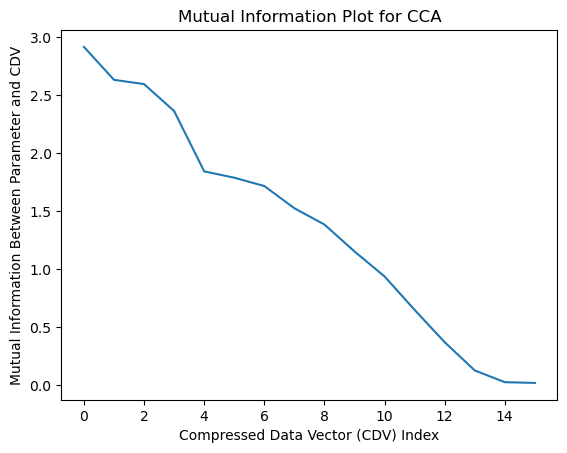

In [8]:
# Compute the sampled parameter auto covariance, simulated data vector auto covariance
# and the parameter-data vector cross covariance
cov = np.cov(data[:,:-2].T, aweights=weight)
cp = cov[np.ix_(index_param, index_param)]
cd = cov[np.ix_(index_map3, index_map3)]
cpd = cov[np.ix_(index_param, index_map3)]

# This 'cl' can be understood as the projection of 'cp' to data vector space
cl = cpd.T@np.linalg.inv(cp)@cpd

# As seen in the paper, this generalized eigenvalue problem is equivalent to CCA
# but is more numerical stable as 'cd' and 'cd-cl' are both invertible.
# This problem is motivated as mutual information maximization under Gaussian linear model assumptions
evals, evecs = scipy.linalg.eigh(cd, cd - cl)

# In the context of the CCA, only min( dim(param), dim(data vector) ) components are real and the rest are noise. 
n = min(index_param.size, index_map3.size)
evals = evals[::-1][:n]
evecs = evecs[:,::-1][:,:n]

plt.title("Mutual Information Plot for CCA")
plt.xlabel("Compressed Data Vector (CDV) Index")
plt.ylabel("Mutual Information Between Parameter and CDV")
plt.plot(np.log(evals)/2)
plt.show()

# compressed_dv = dv_LFI@evecs
# compressed_dv = data[:, index_map3]@evecs

# # PCC = np.abs(np.corrcoef( compressed_dv,pars_LFI, rowvar = False))
# PCC = np.abs(np.corrcoef( compressed_dv, data[:,index_param], rowvar = False))
# makeplot(PCC, 'CCA')

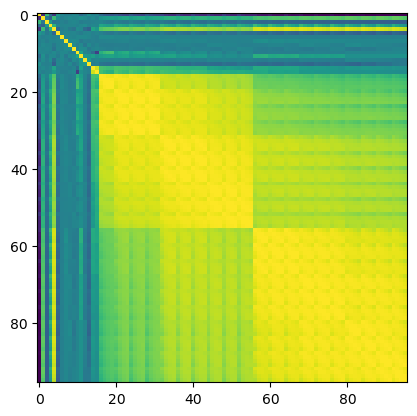

In [9]:
cov_sub = cov[np.ix_(index_joint, index_joint)]
std = np.diag(cov_sub)**0.5
rcc = cov_sub/np.outer(std, std)
plt.imshow(rcc)

In [10]:
evecs.shape

(80, 16)

In [11]:
np.savetxt('evecs_0.txt', evecs)